In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score
from collections import Counter
from rdkit.Chem import AllChem
from rdkit import Chem
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import os

In [2]:
def smiles_to_morgan_fp(smiles: str, n_bits: int = 2048, radius: int = 2) -> np.ndarray:
    """
    Converts a SMILES string to a Morgan fingerprint.
    """
    mol = Chem.MolFromSmiles(smiles)    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

In [3]:
df = pd.read_csv("/home/acomajuncosa/Downloads/activities_CHEMBL1794345.tsv", sep='\t', low_memory=False)
df = df[~df['Smiles'].isna()]
print("No pvalues: " + str([i for i in df['pChEMBL Value'].tolist() if not np.isnan(i)]))
print("All are nM: " + str(set([i for i in df['Standard Units']])))

# Generate pChEMBLs
df['pChEMBL_calculated'] = [-np.log10(i * 1e-09) for i in df['Standard Value']]

# Get actives and inactives
actives = df[df['pChEMBL_calculated'] >= 7]['Smiles'].tolist()
inactives = df[df['pChEMBL_calculated'] < 7]['Smiles'].tolist()
print("Actives: " + str(len(actives)))
print("Inactives: " + str(len(inactives)))

# Fix random seed
np.random.seed(42)

# Choose N actives and 5 * N inactives
N = 2000
selected_actives = np.random.choice(actives, N, replace=False).tolist()
selected_inactives = np.random.choice(inactives, 5 * N, replace=False).tolist()
print("Actives: " + str(len(selected_actives)))
print("Inactives: " + str(len(selected_inactives)))

# Get ECFPs
print("Calculating ECFPs...")
selected_actives = [smiles_to_morgan_fp(i) for i in selected_actives]
selected_inactives = [smiles_to_morgan_fp(i) for i in selected_inactives]

# Create matrices
X = np.array(selected_actives + selected_inactives)
Y = np.array([1]*len(selected_actives) + [0]*len(selected_inactives))
print("Matrix shapes:")
print(X.shape, Y.shape)

No pvalues: []
All are nM: {'nM'}
Actives: 7364
Inactives: 162948
Actives: 2000
Inactives: 10000
Calculating ECFPs...
Matrix shapes:
(12000, 2048) (12000,)


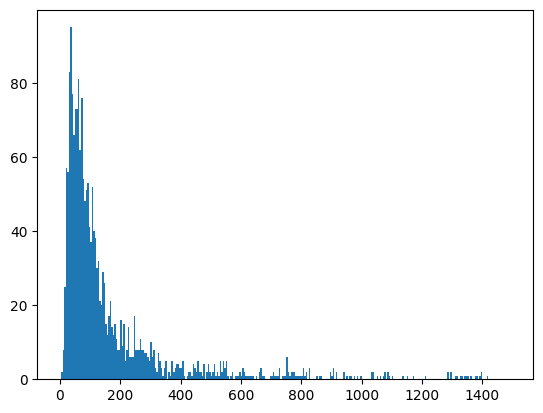

In [4]:
plt.hist(np.sum(X, axis=0), bins=[i for i in range(0, 1500, 5)])
plt.show()

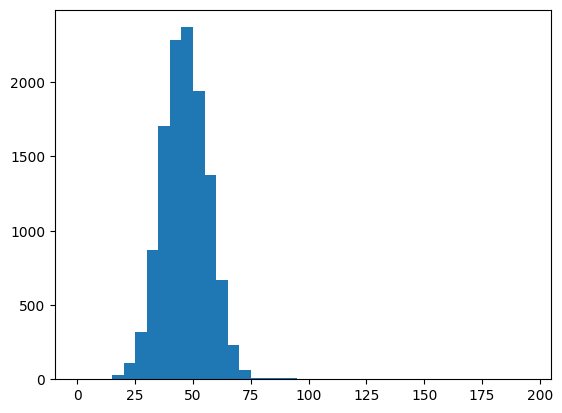

In [5]:
plt.hist(np.sum(X, axis=1), bins=[i for i in range(0, 200, 5)])
plt.show()

In [6]:
# Split into training and test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [13]:
# Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=10, random_state=24, n_jobs=8)
clf.fit(X_train, Y_train)
random.seed(42)
Y_train_shuffled = np.copy(Y_train)
random.shuffle(Y_train_shuffled)
print(f"AUROC TRAIN: {metrics.roc_auc_score(Y_train, clf.predict_proba(X_train)[:,1])}")
print(f"AUROC TRAIN SHUFFLED: {metrics.roc_auc_score(Y_train_shuffled, clf.predict_proba(X_train)[:,1])}")
print(f"AUROC TEST: {metrics.roc_auc_score(Y_test, clf.predict_proba(X_test)[:,1])}")

AUROC TRAIN: 0.9996890234375002
AUROC TRAIN SHUFFLED: 0.5005539453125
AUROC TEST: 0.49011125000000005


In [ ]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression Classifier
clf_lr = LogisticRegression(random_state=42, max_iter=100, n_jobs=8)
clf_lr.fit(X_train, Y_train)

# Calculate AUROC for Train and Test sets
train_auroc = metrics.roc_auc_score(Y_train, clf_lr.predict_proba(X_train)[:, 1])
test_auroc = metrics.roc_auc_score(Y_test, clf_lr.predict_proba(X_test)[:, 1])

print(f"AUROC TRAIN: {train_auroc}")
print(f"AUROC TEST: {test_auroc}")

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn import metrics

# Train a Naive Bayes Classifier (Bernoulli Naive Bayes for binary features)
clf_nb = BernoulliNB()
clf_nb.fit(X_train, Y_train)

# Calculate AUROC for Train and Test sets
train_auroc = metrics.roc_auc_score(Y_train, clf_nb.predict_proba(X_train)[:, 1])
test_auroc = metrics.roc_auc_score(Y_test, clf_nb.predict_proba(X_test)[:, 1])

# Output results
print(f"AUROC TRAIN: {train_auroc}")
print(f"AUROC TEST: {test_auroc}")


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

ind_act = np.where(Y == 1)[0]
ind_inact = np.where(Y == 0)[0]

# Apply PCA for dimensionality reduction to 2D
pca = PCA(n_components=2, random_state=42)
embedding = pca.fit_transform(X)

# Plot the result
plt.figure(figsize=(4, 4))
plt.scatter(embedding[ind_inact][:, 0], embedding[ind_inact][:, 1], s=1, alpha=1, zorder=1)
plt.scatter(embedding[ind_act][:, 0], embedding[ind_act][:, 1], s=1, alpha=1, zorder=2)
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.grid(linestyle='--')
plt.tight_layout()
plt.show()